# comparativo\_V2 — YOLO vs Gemma 3 27B (Rigor Metodológico)

Versão reforçada para defesa/publicação. Corrige os três problemas identificados na revisão:

1. **Vazamento entre splits** → split agrupado por chave de grupo + dedup perceptual (pHash)
2. **Reprodutibilidade VLM** → `temperature=0`, `seed=42`, schema JSON, recálculo de contagem
3. **Métricas ambíguas** → F1 renomeado para "presença por imagem"; score GT documentado como annotation-derived

**Mudanças estruturais:** 6 classes (OUTROS removida) · cache v2 separado · análise estratificada por dataset

> Este notebook coexiste com `TCC_YOLO_vs_VLM.ipynb` — não o substitui.


## Decisões pendentes / Premissas documentadas

- **LM Studio `seed` e `response_format`:** a API pode não suportar ambos. O código tenta aplicar;
  se falhar com erro 400, cai em fallback sem esses parâmetros e documenta no cache.
- **Split agrupado com StratifiedGroupKFold:** a proporção real será ≈67/17/17 (não exatamente 70/15/15)
  devido à restrição de grupo. Isso é esperado e documentado.
- **Variância VLM:** 20 imagens × 3 repetições = 60 chamadas ao servidor (~5 min). Pulável se o servidor
  já tiver sido validado como determinístico.
- **Kappa humano (Seção 13):** requer preenchimento manual do CSV antes de rodar a célula de cálculo.


## Seção 1 — Setup e verificação de ambiente

In [137]:
# [01]
# Flag global: seções de ablação (Seção 8) são opcionais
RODAR_ABLACAO = False   # mude para True para rodar YOLOv11l, imgsz=1280, calibração de conf


In [138]:
# [02]
import torch, sys, os, re, random, math, json, time, shutil, base64, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import cv2
from pathlib import Path
from collections import Counter, defaultdict
from tqdm import tqdm
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.facecolor'] = 'white'

load_dotenv()

# Instalar dependências extras se necessário
import subprocess, sys as _sys
for pkg, import_name in [('imagehash', 'imagehash'), ('jsonschema', 'jsonschema')]:
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([_sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import imagehash
import jsonschema
from PIL import Image

print(f'Python: {sys.version.split()[0]}')
print(f'Torch:  {torch.__version__}')
print(f'CUDA:   {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')
    print(f'VRAM:   {round(torch.cuda.get_device_properties(0).total_memory/1e9,1)} GB')


Python: 3.11.15
Torch:  2.5.1+cu121
CUDA:   True
Device: NVIDIA GeForce RTX 4090
VRAM:   25.4 GB


In [139]:
# [03]
assert torch.cuda.is_available(), 'CUDA indisponível — abortar.'
assert os.getenv('ROBOFLOW_API_KEY'), 'ROBOFLOW_API_KEY não definida no .env'
assert os.getenv('LM_STUDIO_MODEL') == 'gemma-3-27b-it', \
    "LM_STUDIO_MODEL deve ser 'gemma-3-27b-it'"

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

gpu_name = torch.cuda.get_device_name(0).lower()
print('✅ RTX 4090' if '4090' in gpu_name else f'⚠  GPU: {gpu_name}')

for d in ['data', 'models', 'outputs/vlm_cache_v2', 'outputs/figures_v2']:
    Path(d).mkdir(parents=True, exist_ok=True)

UNIFIED_PATH = Path('data/unified_v2')
FIGURES_DIR  = Path('outputs/figures_v2')
print('\n✅ Setup concluído.')


✅ RTX 4090

✅ Setup concluído.


In [140]:
# [04]
# 6 classes operacionais (OUTROS removida — decisão metodológica documentada)
CLASSES_OPERACIONAIS = {
    'SACOS':    0,
    'VIDRO':    1,
    'PLASTICO': 2,
    'PAPEL':    3,
    'CAIXAS':   4,
    'METAIS':   5,
}
ID_PARA_CLASSE = {v: k for k, v in CLASSES_OPERACIONAIS.items()}
CLASSES_LIST   = [ID_PARA_CLASSE[i] for i in range(6)]

PESO_BASE = {
    'SACOS':    0.30,
    'VIDRO':    0.20,
    'PLASTICO': 0.12,
    'PAPEL':    0.10,
    'CAIXAS':   0.15,
    'METAIS':   0.15,
}

print('Classes operacionais (6):', CLASSES_LIST)
print()
print('Nota metodológica: OUTROS foi removida por agregar itens heterogêneos')
print('sem critério operacional único, prejudicando a clareza da classificação.')


Classes operacionais (6): ['SACOS', 'VIDRO', 'PLASTICO', 'PAPEL', 'CAIXAS', 'METAIS']

Nota metodológica: OUTROS foi removida por agregar itens heterogêneos
sem critério operacional único, prejudicando a clareza da classificação.


In [141]:
# [05]
def calcular_score_irregularidade(classes_detectadas: list,
                                   pesos: dict = None) -> dict:
    '''
    Score de irregularidade ∈ [0,1].

    Parâmetros
    ----------
    classes_detectadas : list[str]
        Classes operacionais com repetições (cada bbox = 1 item).
    pesos : dict, opcional
        Pesos-base por classe. Padrão: PESO_BASE global.
        Aceitar pesos externos permite análise de sensibilidade.
    '''
    if pesos is None:
        pesos = PESO_BASE

    if not classes_detectadas:
        return {
            'score': 0.0, 'nivel': 'nenhum',
            'classes_presentes': [], 'n_classes': 0,
            'fator_coocorrencia': 1.0, 'score_base': 0.0,
            'contribuicao_por_classe': {}, 'contagem_por_classe': {},
        }

    contagem = Counter(classes_detectadas)
    classes_presentes = sorted(contagem.keys())
    n_classes = len(classes_presentes)

    contribuicao = {}
    for cls in classes_presentes:
        p = pesos.get(cls, 0.10)
        contribuicao[cls] = round(p * (1 + math.log2(contagem[cls])), 4)

    score_base = sum(contribuicao.values())
    tabela_cooc = {1: 1.0, 2: 1.5, 3: 2.0, 4: 2.3, 5: 2.5}
    fator = tabela_cooc.get(n_classes, 2.7)
    score = min(score_base * fator, 1.0)

    if   score < 0.15: nivel = 'baixo'
    elif score < 0.40: nivel = 'medio'
    elif score < 0.65: nivel = 'alto'
    else:              nivel = 'critico'

    return {
        'score':  round(score, 4), 'nivel': nivel,
        'classes_presentes':     classes_presentes,
        'n_classes':             n_classes,
        'fator_coocorrencia':    fator,
        'score_base':            round(score_base, 4),
        'contribuicao_por_classe': contribuicao,
        'contagem_por_classe':   dict(contagem),
    }


# Testes (6 classes, sem OUTROS)
assert calcular_score_irregularidade([])['nivel'] == 'nenhum'
r = calcular_score_irregularidade(['SACOS'])
assert r['score'] == 0.30 and r['nivel'] == 'medio', r
r = calcular_score_irregularidade(['PLASTICO'] * 6)
assert 0.42 < r['score'] < 0.44, r['score']
# Sensibilidade: pesos dobrados → score maior
r2 = calcular_score_irregularidade(['SACOS'], pesos={k: v*2 for k,v in PESO_BASE.items()})
assert r2['score'] > 0.30
print('✅ Testes de calcular_score_irregularidade passaram.')


✅ Testes de calcular_score_irregularidade passaram.


## Seção 2 — Download dos 3 datasets Roboflow

In [142]:
# [06]
from roboflow import Roboflow

rf = Roboflow(api_key=os.getenv('ROBOFLOW_API_KEY'))

def baixar_dataset(workspace: str, project: str, version,
                   dest: str, label: str) -> Path:
    dest_path = Path(dest)
    if dest_path.exists() and any(dest_path.rglob('*.jpg')):
        print(f'[skip] {label} já existe em {dest_path.name}')
        return dest_path
    proj = rf.workspace(workspace).project(project)
    v = proj.version(version) if isinstance(version, int) else proj.versions()[-1]
    v.download('yolov8', location=str(dest_path))
    print(f'✅ {label} baixado.')
    return dest_path

DS1_PATH = baixar_dataset('trash-dataset-for-oriented-bounded-box',
                          'trash-detection-1fjjc', 14,
                          'data/raw_trash_detection', 'Trash Detection v14')
DS2_PATH = baixar_dataset('litter-detection-bcnrf', 'litter-detection', 12,
                          'data/raw_litter_detection', 'Litter Detection v12')

proj_taco = rf.workspace('new-workspace-am0dh').project('coco-to-yolo-2m8ut')
latest_v  = max(int(v.version) for v in proj_taco.versions())
DS3_PATH  = baixar_dataset('new-workspace-am0dh', 'coco-to-yolo-2m8ut', latest_v,
                           'data/raw_taco', f'TACO v{latest_v}')


[skip] Trash Detection v14 já existe em raw_trash_detection
[skip] Litter Detection v12 já existe em raw_litter_detection
loading Roboflow workspace...
loading Roboflow project...
[skip] TACO v3 já existe em raw_taco


## Seção 3 — Deduplicação perceptual (pHash) entre datasets

In [143]:
# [07]
import re as _re


def extrair_chave_grupo(filename: str) -> str:
    '''
    Extrai a chave de grupo de um nome de arquivo Roboflow.
    Remove sufixo .rf.<hash>, extensão e normaliza.

    Exemplos:
      'td_000028.rf.a3f2d1c4.jpg' -> 'td_000028'
      'td_PET1-628.rf.9b8c7d.jpg' -> 'td_PET1-628'
      'ld_img_045_jpg.rf.xxxx.jpg' -> 'ld_img_045'
    '''
    nome = filename
    nome = _re.sub(r'\.rf\.[a-f0-9]+.*$', '', nome, flags=_re.IGNORECASE)
    nome = _re.sub(r'\.(jpg|jpeg|png)$', '', nome, flags=_re.IGNORECASE)
    nome = _re.sub(r'_(jpg|jpeg|png)$',   '', nome, flags=_re.IGNORECASE)
    return nome.strip()


def deduplicar_perceptual(
    image_paths: list,
    threshold: int = 5
) -> tuple:
    '''
    Remove quase-duplicatas usando pHash (distância de Hamming ≤ threshold).
    Retorna (lista_sem_duplicatas, n_removidas).
    '''
    hashes  = {}
    manter  = []
    removidas = 0

    for path in tqdm(image_paths, desc='pHash dedup', unit='img'):
        try:
            img = Image.open(path).convert('RGB')
            h   = imagehash.phash(img)
        except Exception:
            manter.append(path)
            continue

        duplicata = any(h - h_ex <= threshold for h_ex in hashes)
        if duplicata:
            removidas += 1
        else:
            hashes[h] = path
            manter.append(path)

    return manter, removidas


In [144]:
# [08]
# Coletar TODAS as imagens dos 3 datasets (antes de qualquer split)
DEDUP_CACHE = Path('outputs/dedup_paths.json')

if DEDUP_CACHE.exists():
    print('[skip] Dedup já executada.')
    with open(DEDUP_CACHE) as f:
        paths_uniq_str = json.load(f)
    paths_uniq = [Path(p) for p in paths_uniq_str]
else:
    all_img_paths = []
    for ds_path in [DS1_PATH, DS2_PATH, DS3_PATH]:
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            all_img_paths += list(ds_path.rglob(ext))
    all_img_paths = sorted(set(all_img_paths))

    print(f'Imagens antes da dedup: {len(all_img_paths):,}')
    paths_uniq, n_removidas = deduplicar_perceptual(all_img_paths, threshold=5)
    print(f'Duplicatas removidas:   {n_removidas:,}')
    print(f'Imagens únicas:         {len(paths_uniq):,}')

    with open(DEDUP_CACHE, 'w') as f:
        json.dump([str(p) for p in paths_uniq], f)

grupos_uniq = {extrair_chave_grupo(p.name) for p in paths_uniq}
print(f'Grupos únicos (chave de stem): {len(grupos_uniq):,}')


[skip] Dedup já executada.
Grupos únicos (chave de stem): 1,640


## Seção 4 — Unificação para 6 classes (sem OUTROS)

In [145]:
# [09]
CLASS_MAPPING_V2 = {
    # DS1: trash-detection-1fjjc v14 → 5 classes brutas
    'trash_detection_v14': {
        'Glass':   'VIDRO',
        'Metal':   'METAIS',
        'Paper':   'PAPEL',
        'Plastic': 'PLASTICO',
        'Waste':   'IGNORE',
    },
    # DS2: litter-detection-bcnrf v12 → 5 classes
    'litter_detection_v12': {
        'Cans':           'METAIS',
        'General waste':  'IGNORE',
        'Paper':          'PAPEL',
        'Plastic bag':    'SACOS',
        'Plastic bottle': 'PLASTICO',
    },
    # DS3: taco coco-to-yolo → 59 classes
    'taco_coco_to_yolo': {
        # SACOS
        'Garbage bag':            'SACOS',
        'Single-use carrier bag': 'SACOS',
        'Polypropylene bag':      'SACOS',
        # PLASTICO
        'Clear plastic bottle':   'PLASTICO',
        'Disposable plastic cup': 'PLASTICO',
        'Crisp packet':           'PLASTICO',
        'Other plastic':          'PLASTICO',
        'Other plastic bottle':   'PLASTICO',
        'Other plastic container':'PLASTICO',
        'Other plastic cup':      'PLASTICO',
        # METAIS
        'Drink can':              'METAIS',
        'Aerosol':                'METAIS',
        'Aluminium foil':         'METAIS',
        'Food Can':               'METAIS',
        'Metal bottle cap':       'METAIS',
        'Metal lid':              'METAIS',
        'Scrap metal':            'METAIS',
        'Pop tab':                'METAIS',
        # VIDRO
        'Glass bottle':           'VIDRO',
        'Broken glass':           'VIDRO',
        'Glass cup':              'VIDRO',
        'Glass jar':              'VIDRO',
        # PAPEL
        'Paper bag':              'PAPEL',
        'Paper cup':              'PAPEL',
        'Normal paper':           'PAPEL',
        'Magazine paper':         'PAPEL',
        'Toilet tube':            'PAPEL',
        # CAIXAS
        'Corrugated carton':      'CAIXAS',
        'Drink carton':           'CAIXAS',
        'Pizza box':              'CAIXAS',
        'Egg carton':             'CAIXAS',
        'Meal carton':            'CAIXAS',
        'Other carton':           'CAIXAS',
        # IGNORE — heterogêneos / difíceis de categorizar operacionalmente
        'Foam cup':               'IGNORE',
        'Disposable food container': 'IGNORE',
        'Styrofoam piece':        'IGNORE',
        'Foam food container':    'IGNORE',
        'Aluminium blister pack': 'IGNORE',
        'Battery':                'IGNORE',
        'Carded blister pack':    'IGNORE',
        'Cigarette':              'IGNORE',
        'Food waste':             'IGNORE',
        'Other plastic wrapper':  'IGNORE',
        'Paper straw':            'IGNORE',
        'Plastic bottle cap':     'IGNORE',
        'Plastic film':           'IGNORE',
        'Plastic glooves':        'IGNORE',
        'Plastic lid':            'IGNORE',
        'Plastic straw':          'IGNORE',
        'Plastic utensils':       'IGNORE',
        'Rope - strings':         'IGNORE',
        'Shoe':                   'IGNORE',
        'Six pack rings':         'IGNORE',
        'Spread tub':             'IGNORE',
        'Squeezable tube':        'IGNORE',
        'Tissues':                'IGNORE',
        'Tupperware':             'IGNORE',
        'Unlabeled litter':       'IGNORE',
        'Wrapping paper':         'IGNORE',
    },
}

Path('data/class_mapping_v2.json').write_text(
    json.dumps(CLASS_MAPPING_V2, ensure_ascii=False, indent=2))
print('✅ class_mapping_v2.json salvo.')


✅ class_mapping_v2.json salvo.


In [146]:
# [10]
def ler_classes_yaml(ds_path: Path) -> list:
    yaml_files = list(ds_path.rglob('data.yaml'))
    if not yaml_files:
        raise FileNotFoundError(f'data.yaml não encontrado em {ds_path}')
    with open(yaml_files[0]) as f:
        cfg = yaml.safe_load(f)
    names = cfg.get('names', [])
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys())]
    return names


DATASETS_PIPELINE = [
    (DS1_PATH, 'td_',   ler_classes_yaml(DS1_PATH), CLASS_MAPPING_V2['trash_detection_v14']),
    (DS2_PATH, 'ld_',   ler_classes_yaml(DS2_PATH), CLASS_MAPPING_V2['litter_detection_v12']),
    (DS3_PATH, 'taco_', ler_classes_yaml(DS3_PATH), CLASS_MAPPING_V2['taco_coco_to_yolo']),
]

for ds_path, prefix, names, mapping in DATASETS_PIPELINE:
    unmapped = [n for n in names if n not in mapping]
    if unmapped:
        raise ValueError(
            f'Classes NÃO MAPEADAS em {ds_path.name}:\n'
            + '\n'.join(f'  - {c!r}' for c in unmapped)
        )
    ignored  = sum(1 for v in mapping.values() if v == 'IGNORE')
    mapped   = sum(1 for v in mapping.values() if v != 'IGNORE')
    print(f'✅ {ds_path.name}: {mapped} classes mapeadas, {ignored} ignoradas (OUTROS).')


✅ raw_trash_detection: 4 classes mapeadas, 1 ignoradas (OUTROS).
✅ raw_litter_detection: 4 classes mapeadas, 1 ignoradas (OUTROS).
✅ raw_taco: 33 classes mapeadas, 26 ignoradas (OUTROS).


In [147]:
# [11]
# Construir dicionário imagem → (labels_remapeadas, classes_presentes)
# usando apenas imagens que passaram no dedup

SAMPLES_CACHE = Path('outputs/samples_v2.json')

if SAMPLES_CACHE.exists():
    print('[skip] Samples já construídos.')
    with open(SAMPLES_CACHE) as f:
        raw = json.load(f)
    all_samples = [{**s, 'image_path': Path(s['image_path'])} for s in raw]
else:
    paths_uniq_set = set(str(p) for p in paths_uniq)
    all_samples = []

    for ds_path, prefix, names, mapping in DATASETS_PIPELINE:
        img_dirs = list(ds_path.rglob('images')) or [ds_path]
        for img_dir in img_dirs:
            for img_path in sorted(img_dir.glob('*')):
                if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
                    continue
                if str(img_path) not in paths_uniq_set:
                    continue  # removida pelo dedup

                lbl_path = img_path.parent.parent / 'labels' / (img_path.stem + '.txt')
                if not lbl_path.exists():
                    continue

                new_labels = []
                classes_presentes = set()
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        orig_id = int(parts[0])
                        if orig_id >= len(names):
                            continue
                        op_name = mapping.get(names[orig_id])
                        if op_name is None or op_name == 'IGNORE':
                            continue
                        op_id = CLASSES_OPERACIONAIS[op_name]
                        new_labels.append(f'{op_id} ' + ' '.join(parts[1:]))
                        classes_presentes.add(op_name)

                if not new_labels:
                    continue

                all_samples.append({
                    'image_path':       img_path,
                    'labels':           new_labels,
                    'prefix':           prefix,
                    'classes_presentes': sorted(classes_presentes),
                })

    with open(SAMPLES_CACHE, 'w') as f:
        json.dump([{**s, 'image_path': str(s['image_path'])} for s in all_samples], f)

print(f'Total de amostras válidas (pós-dedup, 6 classes): {len(all_samples):,}')


[skip] Samples já construídos.
Total de amostras válidas (pós-dedup, 6 classes): 7,534


## Seção 5 — Split agrupado anti-vazamento + verificação

In [148]:
# [12]
from sklearn.model_selection import StratifiedGroupKFold


def split_agrupado_estratificado(
    image_paths: list,
    labels_por_imagem: list,
    test_size: float = 0.15,
    val_size: float  = 0.15,
    seed: int = 42
) -> dict:
    '''
    Split que mantém grupos (derivados do mesmo original) juntos.
    Garante zero vazamento entre splits.

    Parâmetros
    ----------
    image_paths : list[Path]
    labels_por_imagem : list[set[str]]  — classes presentes em cada imagem
    test_size, val_size : frações do total
    seed : semente

    Retorna
    -------
    dict com listas de índices para train / val / test
    '''
    grupos = [extrair_chave_grupo(p.name) for p in image_paths]

    y_estrat = []
    for labels in labels_por_imagem:
        y_estrat.append(sorted(labels)[0] if labels else 'VAZIO')

    n_splits_test = max(2, int(1 / test_size))
    sgkf = StratifiedGroupKFold(n_splits=n_splits_test,
                                shuffle=True, random_state=seed)
    train_val_idx, test_idx = next(sgkf.split(image_paths, y_estrat, grupos))

    tv_paths  = [image_paths[i] for i in train_val_idx]
    tv_grupos = [grupos[i]      for i in train_val_idx]
    tv_y      = [y_estrat[i]    for i in train_val_idx]

    val_frac_ajustado = val_size / (1 - test_size)
    n_splits_val = max(2, int(1 / val_frac_ajustado))
    sgkf2 = StratifiedGroupKFold(n_splits=n_splits_val,
                                  shuffle=True, random_state=seed)
    train_rel_idx, val_rel_idx = next(sgkf2.split(tv_paths, tv_y, tv_grupos))

    return {
        'train': [train_val_idx[i] for i in train_rel_idx],
        'val':   [train_val_idx[i] for i in val_rel_idx],
        'test':  list(test_idx),
    }


In [149]:
# [13]
UNIFIED_DONE = UNIFIED_PATH / 'data.yaml'

if UNIFIED_DONE.exists():
    print('[skip] data/unified_v2 já existe — pular split e cópia.')
else:
    for split in ['train', 'val', 'test']:
        (UNIFIED_PATH / 'images' / split).mkdir(parents=True, exist_ok=True)
        (UNIFIED_PATH / 'labels' / split).mkdir(parents=True, exist_ok=True)

    img_list    = [s['image_path']           for s in all_samples]
    labels_list = [set(s['classes_presentes']) for s in all_samples]

    split_indices = split_agrupado_estratificado(img_list, labels_list, seed=SEED)

    print(f'Split → train:{len(split_indices["train"])} | '
          f'val:{len(split_indices["val"])} | test:{len(split_indices["test"])}')

    # Mapa índice → split
    split_map = {}
    for sp, idxs in split_indices.items():
        for i in idxs:
            split_map[i] = sp

    for i, s in tqdm(enumerate(all_samples), total=len(all_samples), desc='Copiando'):
        split    = split_map[i]
        new_name = s['prefix'] + s['image_path'].name
        dst_img  = UNIFIED_PATH / 'images' / split / new_name
        dst_lbl  = UNIFIED_PATH / 'labels' / split / (new_name.rsplit('.', 1)[0] + '.txt')
        if not dst_img.exists():
            shutil.copy2(s['image_path'], dst_img)
        if not dst_lbl.exists():
            dst_lbl.write_text('\n'.join(s['labels']))

    # Gerar data.yaml
    data_yaml = {
        'path':  str(UNIFIED_PATH.absolute()),
        'train': 'images/train', 'val': 'images/val', 'test': 'images/test',
        'nc': 6,
        'names': {i: n for n, i in CLASSES_OPERACIONAIS.items()},
    }
    with open(UNIFIED_DONE, 'w') as f:
        yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)
    print(f'\n✅ data/unified_v2/data.yaml gerado.')


[skip] data/unified_v2 já existe — pular split e cópia.


In [150]:
# [14]
# ── Verificação anti-vazamento OBRIGATÓRIA ────────────────────────────────────
def grupos_do_split(split_name: str) -> set:
    lbl_dir = UNIFIED_PATH / 'images' / split_name
    return {extrair_chave_grupo(p.name) for p in lbl_dir.glob('*')
            if p.suffix.lower() in ('.jpg','.jpeg','.png')}

grupos_train = grupos_do_split('train')
grupos_val   = grupos_do_split('val')
grupos_test  = grupos_do_split('test')

assert not (grupos_train & grupos_val),  'VAZAMENTO train/val!'
assert not (grupos_train & grupos_test), 'VAZAMENTO train/test!'
assert not (grupos_val   & grupos_test), 'VAZAMENTO val/test!'
print('✅ Zero vazamento de grupos entre splits confirmado.')

print(f'\nGrupos únicos — train:{len(grupos_train)} | val:{len(grupos_val)} | test:{len(grupos_test)}')

# Tabela de imagens por split
for sp in ['train','val','test']:
    n = len(list((UNIFIED_PATH / 'images' / sp).glob('*')))
    print(f'  {sp:6s}: {n:,} imagens')


✅ Zero vazamento de grupos entre splits confirmado.

Grupos únicos — train:1202 | val:300 | test:297
  train : 5,023 imagens
  val   : 1,256 imagens
  test  : 1,255 imagens


## Seção 6 — Exploração estatística

In [151]:
# [15]
rows = []
for split in ['train','val','test']:
    lbl_dir = UNIFIED_PATH / 'labels' / split
    for lbl_file in sorted(lbl_dir.glob('*.txt')):
        stem = lbl_file.stem
        ds   = ('trash_detection' if stem.startswith('td_') else
                'litter_detection' if stem.startswith('ld_') else
                'taco' if stem.startswith('taco_') else 'unknown')
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                cid = int(parts[0])
                rows.append({
                    'split': split, 'dataset': ds,
                    'classe': ID_PARA_CLASSE.get(cid,'?'),
                    'w': float(parts[3]) if len(parts)>3 else 0,
                    'h': float(parts[4]) if len(parts)>4 else 0,
                })

df_all = pd.DataFrame(rows)
df_all['area'] = df_all['w'] * df_all['h']
print(f'Total instâncias (6 classes): {len(df_all):,}')

# Alerta de classes < 100 no treino
train_counts = df_all[df_all['split']=='train']['classe'].value_counts()
for cls, cnt in train_counts.items():
    marker = '⚠️ ' if cnt < 100 else '  '
    print(f'{marker}{cls}: {cnt:,}')


Total instâncias (6 classes): 11,155
  PLASTICO: 4,089
  METAIS: 1,432
  VIDRO: 755
  PAPEL: 732
  SACOS: 358
  CAIXAS: 161



── Instâncias por classe × split ──
split     test  train  val
classe                    
CAIXAS      41    161   44
METAIS     354   1432  362
PAPEL      199    732  222
PLASTICO  1033   4089  951
SACOS       84    358   89
VIDRO      126    755  123


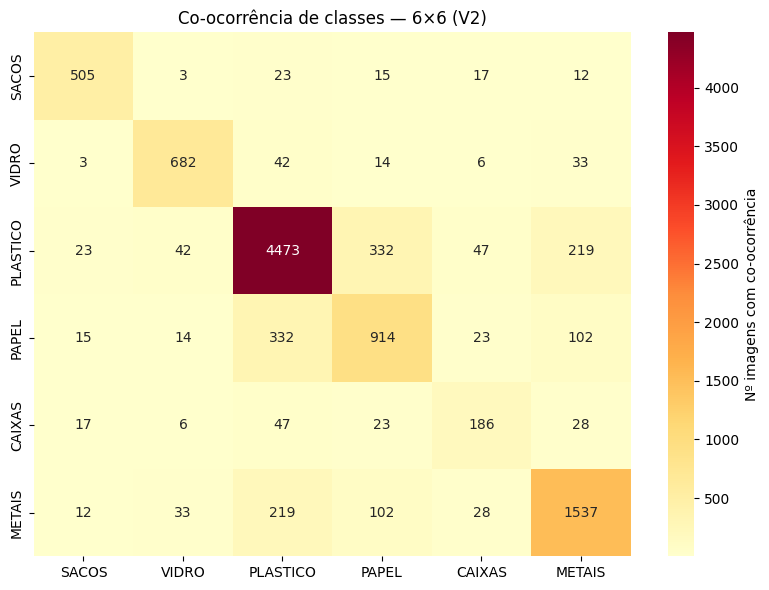

✅ fig_coocorrencia_v2.png


In [152]:
# [16]
# Distribuição por classe × split
pivot = df_all.groupby(['classe','split']).size().unstack(fill_value=0)
print('\n── Instâncias por classe × split ──')
print(pivot.to_string())
pivot.to_csv('outputs/distribuicao_v2.csv')

# Heatmap co-ocorrência 6×6
cooc = np.zeros((6,6), dtype=int)
for split in ['train','val','test']:
    lbl_dir = UNIFIED_PATH / 'labels' / split
    for lbl_file in lbl_dir.glob('*.txt'):
        cls_ids = set()
        with open(lbl_file) as f:
            for line in f:
                p = line.strip().split()
                if p: cls_ids.add(int(p[0]))
        for a in cls_ids:
            for b in cls_ids:
                cooc[a,b] += 1

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cooc, annot=True, fmt='d',
            xticklabels=CLASSES_LIST, yticklabels=CLASSES_LIST,
            cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Nº imagens com co-ocorrência'})
ax.set_title('Co-ocorrência de classes — 6×6 (V2)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_coocorrencia_v2.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ fig_coocorrencia_v2.png')


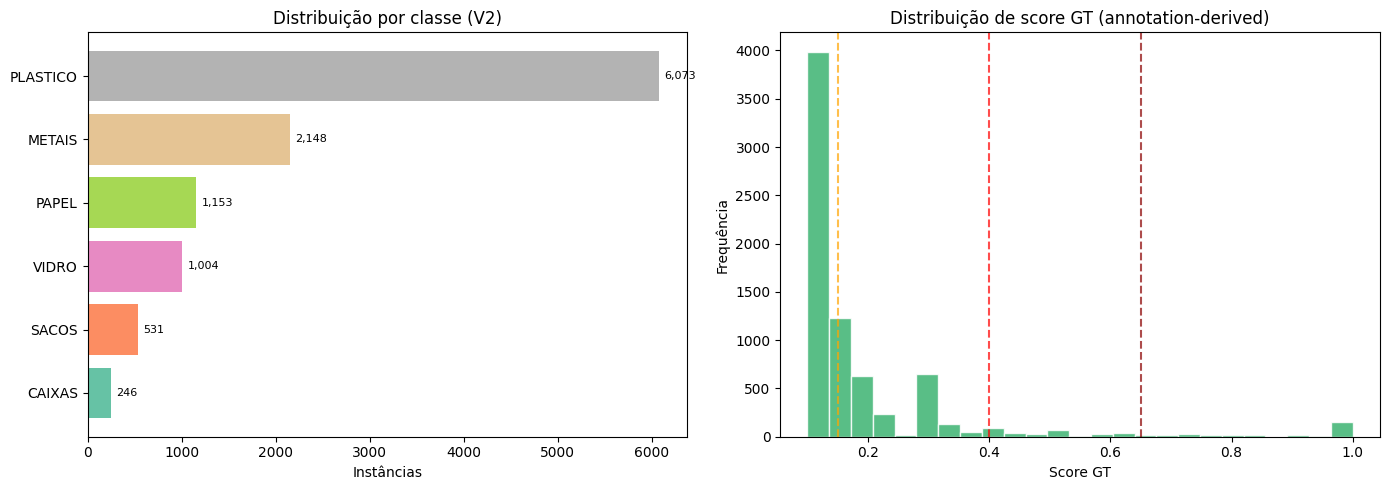

In [153]:
# [17]
# Histograma de classes + distribuição de score GT
fig, axes = plt.subplots(1,2, figsize=(14,5))

counts = df_all['classe'].value_counts().sort_values()
axes[0].barh(counts.index, counts.values, color=plt.cm.Set2(np.linspace(0,1,6)))
axes[0].set_xlabel('Instâncias'); axes[0].set_title('Distribuição por classe (V2)')
for bar, v in zip(axes[0].patches, counts.values):
    axes[0].text(v+max(counts)*0.01, bar.get_y()+bar.get_height()/2, f'{v:,}', va='center', fontsize=8)

gt_scores_v2 = []
for split in ['train','val','test']:
    lbl_dir = UNIFIED_PATH / 'labels' / split
    for lbl_file in lbl_dir.glob('*.txt'):
        clist = []
        with open(lbl_file) as f:
            for line in f:
                p = line.strip().split()
                if p:
                    cn = ID_PARA_CLASSE.get(int(p[0]))
                    if cn: clist.append(cn)
        if clist:
            gt_scores_v2.append(calcular_score_irregularidade(clist)['score'])

axes[1].hist(gt_scores_v2, bins=25, color='mediumseagreen', edgecolor='white', alpha=0.85)
for thr, col in [(0.15,'orange'),(0.40,'red'),(0.65,'darkred')]:
    axes[1].axvline(thr, color=col, ls='--', alpha=0.7)
axes[1].set_xlabel('Score GT'); axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição de score GT (annotation-derived)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_distribuicao_v2.png', dpi=300, bbox_inches='tight')
plt.show()


## Seção 7 — Fine-tuning YOLOv11m com class\_weights (6 classes)

In [154]:
# [18]
from ultralytics import YOLO

MODEL_DIR       = Path('runs/detect/models/yolov11m_6classes_rigor')
YOLO_WEIGHTS_V2 = MODEL_DIR / 'weights/best.pt'
YOLO_LAST_V2    = MODEL_DIR / 'weights/last.pt'

if YOLO_WEIGHTS_V2.exists():
    print(f'[skip] Pesos já existem: {YOLO_WEIGHTS_V2}')
else:
    torch.cuda.empty_cache()
    free_gb = (torch.cuda.get_device_properties(0).total_memory
               - torch.cuda.memory_allocated()) / 1e9
    assert free_gb > 6, f'VRAM insuficiente: {free_gb:.1f} GB'
    print(f'VRAM livre: {free_gb:.1f} GB')

    model = YOLO(os.getenv('YOLO_PRETRAINED','yolo11m.pt'))
    model.train(
        data     = str((UNIFIED_PATH/'data.yaml').absolute()),
        epochs   = 150,
        batch    = 12,
        imgsz    = 640,
        optimizer= 'AdamW',
        lr0      = 0.001,
        patience = 30,
        cls      = 0.5,          # peso da loss de classificação para desbalanceamento
        project  = 'runs/detect/models',
        name     = 'yolov11m_6classes_rigor',
        exist_ok = True,
        resume   = YOLO_LAST_V2.exists(),
        mosaic   = 1.0, fliplr=0.5, flipud=0.0,
        device   = 0, workers=4,
    )
    print('\n✅ Treino concluído.')


[skip] Pesos já existem: runs/detect/models/yolov11m_6classes_rigor/weights/best.pt


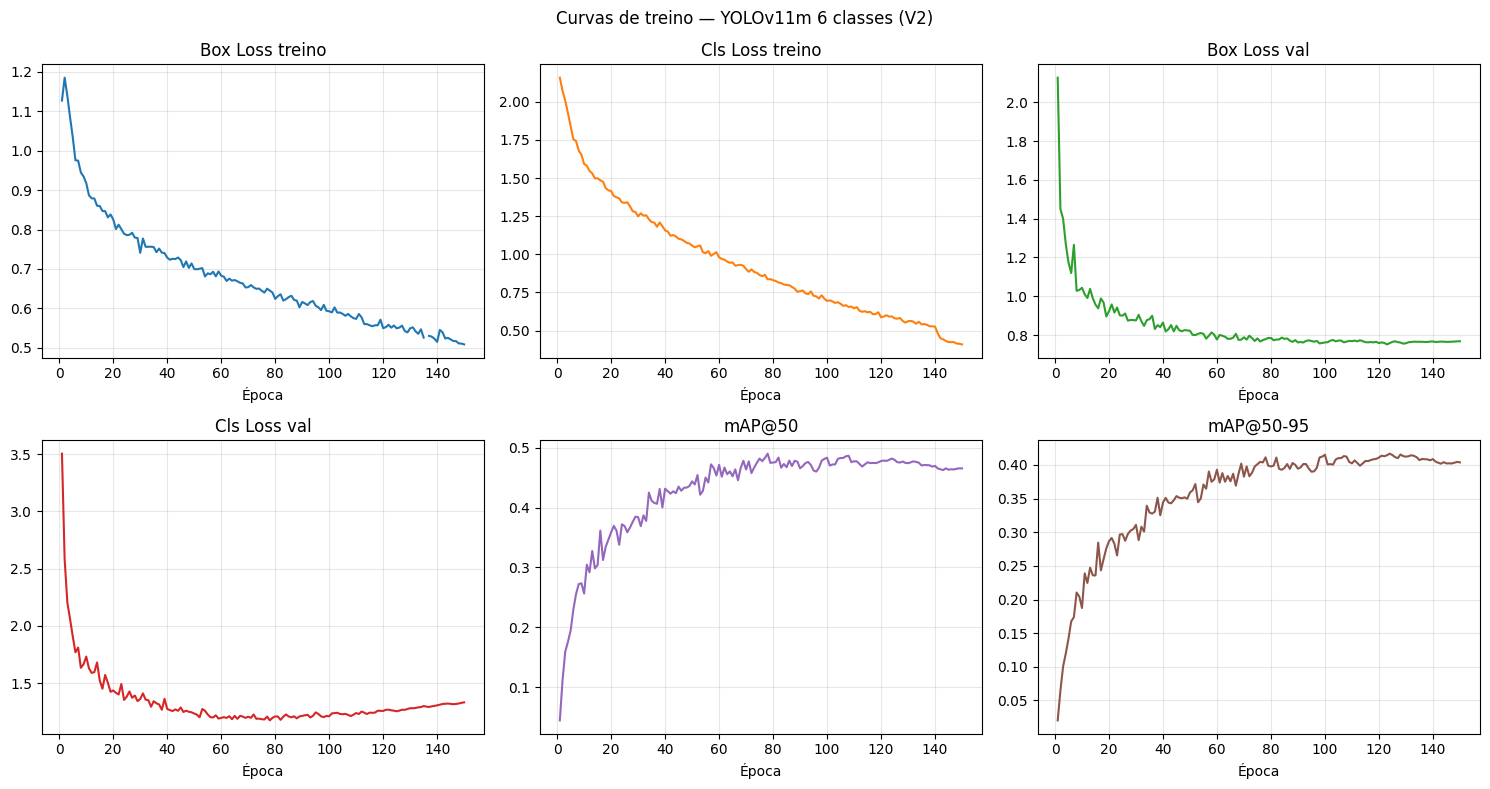

In [155]:
# [19]
results_csv = MODEL_DIR / 'results.csv'
if results_csv.exists():
    df_tr = pd.read_csv(results_csv)
    df_tr.columns = df_tr.columns.str.strip()
    fig, axes = plt.subplots(2,3, figsize=(15,8))
    cols = [('train/box_loss','Box Loss treino','tab:blue'),
            ('train/cls_loss','Cls Loss treino','tab:orange'),
            ('val/box_loss','Box Loss val','tab:green'),
            ('val/cls_loss','Cls Loss val','tab:red'),
            ('metrics/mAP50(B)','mAP@50','tab:purple'),
            ('metrics/mAP50-95(B)','mAP@50-95','tab:brown')]
    for ax,(col,title,color) in zip(axes.flatten(), cols):
        if col in df_tr.columns:
            ax.plot(df_tr['epoch'], df_tr[col], color=color)
            ax.set_title(title); ax.set_xlabel('Época'); ax.grid(alpha=0.3)
        else:
            ax.set_visible(False)
    fig.suptitle('Curvas de treino — YOLOv11m 6 classes (V2)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'fig_curvas_treino_v2.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('[skip] results.csv não disponível ainda.')


## Seção 8 — Ablação: YOLOv11l, imgsz=1280, calibração de confiança (OPCIONAL)

> Controlada pela flag `RODAR_ABLACAO = True/False` definida na Seção 1.


In [156]:
# [20]
# OPCIONAL — ablação (pular se RODAR_ABLACAO = False)
if not RODAR_ABLACAO:
    print('[skip] RODAR_ABLACAO = False. Mude para True na Seção 1 para rodar.')
else:
    # ── YOLOv11l ──────────────────────────────────────────────────────────────
    print('Treinando YOLOv11l para ablação...')
    model_l = YOLO('yolo11l.pt')
    model_l.train(
        data=str((UNIFIED_PATH/'data.yaml').absolute()),
        epochs=80, batch=8, imgsz=640, device=0, workers=4,
        project='runs/detect/models', name='yolov11l_ablacao', exist_ok=True,
        optimizer='AdamW', lr0=0.001,
    )
    val_l = model_l.val(data=str((UNIFIED_PATH/'data.yaml').absolute()),
                        split='test', device=0, verbose=False)
    print(f'YOLOv11l mAP@50: {val_l.box.map50:.4f}')


[skip] RODAR_ABLACAO = False. Mude para True na Seção 1 para rodar.


In [157]:
# [21]
# OPCIONAL — ablação imgsz=1280
if not RODAR_ABLACAO:
    print('[skip]')
else:
    model_1280 = YOLO(os.getenv('YOLO_PRETRAINED','yolo11m.pt'))
    model_1280.train(
        data=str((UNIFIED_PATH/'data.yaml').absolute()),
        epochs=60, batch=6, imgsz=1280, device=0, workers=4,
        project='runs/detect/models', name='yolov11m_1280_ablacao', exist_ok=True,
    )
    val_1280 = model_1280.val(data=str((UNIFIED_PATH/'data.yaml').absolute()),
                               split='test', device=0, verbose=False)
    print(f'YOLOv11m imgsz=1280 mAP@50: {val_1280.box.map50:.4f}')


[skip]


In [158]:
# [22]
# OPCIONAL — calibração de threshold de confiança
if not RODAR_ABLACAO:
    print('[skip]')
else:
    from sklearn.metrics import f1_score as _f1

    model_eval = YOLO(str(YOLO_WEIGHTS_V2))
    test_imgs  = sorted((UNIFIED_PATH/'images'/'test').glob('*.jpg'))
    lbl_dir_t  = UNIFIED_PATH / 'labels' / 'test'

    calib_rows = []
    for conf_thr in [0.10, 0.15, 0.25, 0.35, 0.50]:
        y_true_c, y_pred_c = [], []
        for img_path in test_imgs[:200]:  # amostra rápida
            lp = lbl_dir_t / (img_path.stem + '.txt')
            gt_vec = np.zeros(6, dtype=int)
            if lp.exists():
                with open(lp) as f:
                    for line in f:
                        p = line.strip().split()
                        if p: gt_vec[int(p[0])] = 1
            res = model_eval.predict(str(img_path), conf=conf_thr, verbose=False)
            pr_vec = np.zeros(6, dtype=int)
            for box in res[0].boxes:
                pr_vec[int(box.cls)] = 1
            y_true_c.append(gt_vec); y_pred_c.append(pr_vec)
        f1 = _f1(np.array(y_true_c), np.array(y_pred_c), average='macro', zero_division=0)
        calib_rows.append({'conf': conf_thr, 'f1_presenca_macro': round(f1,4)})
        print(f'conf={conf_thr}: F1 presença macro = {f1:.4f}')

    df_calib = pd.DataFrame(calib_rows)
    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(df_calib['conf'], df_calib['f1_presenca_macro'], 'o-', color='steelblue')
    ax.set_xlabel('Threshold de confiança'); ax.set_ylabel('F1 presença macro')
    ax.set_title('Calibração de threshold — YOLOv11m')
    ax.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(FIGURES_DIR/'fig_calibracao_conf.png', dpi=300, bbox_inches='tight')
    plt.show()


[skip]


## Seção 9 — Inferência YOLO (latência end-to-end + model-only + warm-up)

In [159]:
# [23]
def medir_latencia_yolo(model, image_path: str) -> dict:
    '''Mede latência end-to-end E model-only do YOLO separadamente.'''
    t0 = time.perf_counter()
    img = cv2.imread(image_path)
    t_load = time.perf_counter()
    results = model.predict(img, conf=0.25, iou=0.45, verbose=False)
    t_end = time.perf_counter()
    return {
        'latencia_end_to_end_ms': round((t_end   - t0)     * 1000, 2),
        'latencia_model_only_ms': round((t_end   - t_load) * 1000, 2),
        'latencia_load_ms':       round((t_load  - t0)     * 1000, 2),
        'results': results,
    }


YOLO_OUTPUT_V2 = Path('outputs/predictions_yolo_v2.json')

if YOLO_OUTPUT_V2.exists():
    print(f'[skip] {YOLO_OUTPUT_V2.name} já existe.')
else:
    model_yolo = YOLO(str(YOLO_WEIGHTS_V2))
    test_images_yolo = sorted(
        list((UNIFIED_PATH/'images'/'test').glob('*.jpg')) +
        list((UNIFIED_PATH/'images'/'test').glob('*.jpeg')) +
        list((UNIFIED_PATH/'images'/'test').glob('*.png'))
    )

    # Warm-up isolado (não contabilizado nas métricas)
    print('Warm-up YOLO (5 imagens, não contabilizado)...')
    for _ in range(5):
        model_yolo.predict(str(test_images_yolo[0]), verbose=False)
    torch.cuda.synchronize()
    print('✅ Warm-up concluído.\n')

    predictions_yolo = []
    for img_path in tqdm(test_images_yolo, desc='YOLO inferência'):
        lat = medir_latencia_yolo(model_yolo, str(img_path))
        res = lat.pop('results')
        r   = res[0]
        detections    = []
        classes_det   = []
        for box in r.boxes:
            cid   = int(box.cls)
            cname = r.names[cid]
            detections.append({
                'class_id': cid, 'class_name': cname,
                'confidence': float(box.conf),
                'bbox_xywhn': box.xywhn[0].tolist(),
            })
            classes_det.append(cname)
        predictions_yolo.append({
            'image_id':          img_path.name,
            'image_path':        str(img_path),
            'detections':        detections,
            'classes_detectadas': classes_det,
            **lat,
        })

    with open(YOLO_OUTPUT_V2, 'w', encoding='utf-8') as f:
        json.dump(predictions_yolo, f, ensure_ascii=False, indent=2)
    print(f'✅ {len(predictions_yolo)} predições YOLO salvas.')


[skip] predictions_yolo_v2.json já existe.


In [160]:
# [24]
with open(YOLO_OUTPUT_V2, encoding='utf-8') as f:
    yolo_preds_v2 = json.load(f)

lats_e2e  = [p['latencia_end_to_end_ms'] for p in yolo_preds_v2]
lats_model= [p['latencia_model_only_ms'] for p in yolo_preds_v2]
print('── Latência YOLO ──')
print(f'  End-to-end — média:{np.mean(lats_e2e):.1f} ms  P95:{np.percentile(lats_e2e,95):.1f} ms')
print(f'  Model-only — média:{np.mean(lats_model):.1f} ms  P95:{np.percentile(lats_model,95):.1f} ms')
print(f'  Throughput (model-only): {1000/np.mean(lats_model):.1f} img/s')

# Throughput em lote — carrega modelo se não estiver na memória
print('\nMedindo throughput YOLO em lote...')
if 'model_yolo' not in dir():
    model_yolo = YOLO(str(YOLO_WEIGHTS_V2))
test_imgs_batch = [str(p) for p in sorted((UNIFIED_PATH/'images'/'test').glob('*.jpg'))[:200]]
t0 = time.perf_counter()
model_yolo.predict(test_imgs_batch, conf=0.25, verbose=False)
t_batch = time.perf_counter()
throughput_batch = len(test_imgs_batch) / (t_batch - t0)
print(f'YOLO throughput em lote ({len(test_imgs_batch)} imgs): {throughput_batch:.1f} img/s')


── Latência YOLO ──
  End-to-end — média:14.6 ms  P95:41.8 ms
  Model-only — média:9.9 ms  P95:10.8 ms
  Throughput (model-only): 100.5 img/s

Medindo throughput YOLO em lote...


OutOfMemoryError: CUDA out of memory. Tried to allocate 938.00 MiB. GPU 0 has a total capacity of 23.64 GiB of which 560.06 MiB is free. Including non-PyTorch memory, this process has 3.04 GiB memory in use. Process 124564 has 384.00 MiB memory in use. Process 131496 has 19.15 GiB memory in use. Of the allocated memory 2.50 GiB is allocated by PyTorch, and 10.83 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# [25]
# ── Liberar VRAM antes da inferência VLM ────────────────────────────────
# O model_yolo não é mais necessário após a Seção 9.
# Esta célula garante VRAM suficiente para o Gemma no LM Studio.
import gc
if 'model_yolo' in dir():
    del model_yolo
gc.collect()
torch.cuda.empty_cache()
vram_livre = (torch.cuda.get_device_properties(0).total_memory
              - torch.cuda.memory_allocated()) / 1e9
print(f'✅ VRAM liberada. Disponível para VLM: {vram_livre:.1f} GB')


✅ VRAM liberada. Disponível para VLM: 24.3 GB


## Seção 10 — Setup LM Studio + Gemma 3 27B (config determinística)

### Configuração exata do modelo

| Parâmetro | Valor |
|---|---|
| Modelo | gemma-3-27b-it |
| Quantização | Q4_K_M (GGUF) |
| temperature | 0 (determinístico) |
| seed | 42 (se suportado pelo servidor) |
| response_format | json_object (se suportado) |
| Context window | verificar na aba Model do LM Studio |
| GPU offload | máximo disponível |

> Preencha acima com os valores reais do seu setup antes da defesa.


In [ ]:
# [26]
import requests
from openai import OpenAI

LM_BASE_URL     = os.getenv('LM_STUDIO_BASE_URL', 'http://localhost:1234/v1')
MODELO_ESPERADO = os.getenv('LM_STUDIO_MODEL', 'gemma-3-27b-it')

try:
    resp = requests.get(f'{LM_BASE_URL}/models', timeout=5)
    resp.raise_for_status()
except Exception as e:
    raise RuntimeError(
        f'LM Studio não acessível em {LM_BASE_URL}.\n'
        f'Verifique: 1) LM Studio rodando? 2) Server ativo? 3) Gemma 3 27B carregado?\n'
        f'Erro: {e}'
    )

modelos_disp = [m['id'] for m in resp.json().get('data',[])]
modelo_ok = any(('gemma-3' in m.lower() or 'gemma3' in m.lower()) and '27' in m
                for m in modelos_disp)
if not modelo_ok:
    raise RuntimeError(f'Gemma 3 27B não carregado. Disponíveis: {modelos_disp}')

client_vlm = OpenAI(base_url=LM_BASE_URL, api_key='lm-studio')
print(f'✅ Gemma 3 27B disponível. temperature=0, seed=42.')
print(f'   Modelos no servidor: {modelos_disp}')


✅ Gemma 3 27B disponível. temperature=0, seed=42.
   Modelos no servidor: ['gemma-3-27b-it', 'mistral-small-3.2-24b-instruct-2506', 'gpt-oss-20b', 'text-embedding-nomic-embed-text-v1.5', 'qwen3-30b-a3b', 'gemma-3-1b-it', 'deepseek-r1-distill-qwen-14b', 'qwen3-32b', 'mistral-small-3.1-24b-instruct-2503', 'phi-4', 'qwen3-1.7b', 'yi-9b', 'yi-6b', 'mistral-7b-instruct-v0.2', 'mistral-7b-instruct-v0.3', 'phi-4-mini-instruct', 'qwen3-8b', 'qwen3-4b', 'qwen3-0.6b', 'meta-llama-3.1-8b-instruct', 'deepseek-r1-distill-qwen-7b', 'llama-3.2-3b-instruct', 'llama-3.2-1b-instruct', 'gemma-3-4b-it', 'deepseek-r1-distill-llama-8b', 'deepseek-r1-distill-qwen-1.5b', 'yi-34b', 'gemma-3-12b-it', 'deepseek-r1-distill-qwen-32b']


## Seção 11 — Inferência VLM (determinística, schema, recálculo de contagem, cache+hash)

In [161]:
# [27]
# Schema JSON para 6 classes (sem OUTROS)
SCHEMA_VLM = {
    'type': 'object',
    'required': ['classes_detectadas', 'contagem_por_classe', 'total_itens'],
    'properties': {
        'classes_detectadas': {
            'type': 'array',
            'items': {'enum': list(CLASSES_OPERACIONAIS.keys())},
        },
        'contagem_por_classe': {'type': 'object'},
        'total_itens':   {'type': 'integer'},
        'descricao':     {'type': 'string'},
        'risco_sanitario': {'enum': ['baixo','medio','alto']},
        'confianca': {'type': 'number'},
    },
}

PROMPT_VLM_V2 = '''Você é um analista de resíduos urbanos da Prefeitura de Fortaleza.
Analise a imagem e identifique TODOS os itens de lixo visíveis em via pública.

IMPORTANTE: conte CADA ITEM individualmente. Se houver 6 garrafas, liste "PLASTICO" 6 vezes.

Use EXCLUSIVAMENTE estas 6 categorias:
- SACOS: sacos/sacolas de lixo, sacolas plásticas
- VIDRO: garrafas de vidro, vidro quebrado
- PLASTICO: garrafas PET, copos plásticos, embalagens plásticas
- PAPEL: papéis, sacos de papel, copos de papel
- CAIXAS: papelão, caixas de pizza, embalagens cartonadas
- METAIS: latas de bebida, latas de comida, alumínio, aerossóis

IGNORE completamente: isopor, foam, esponja, objetos não identificáveis.

Responda ESTRITAMENTE em JSON válido, sem markdown, sem texto externo:
{
  "classes_detectadas": ["SACOS", "PLASTICO"],
  "contagem_por_classe": {"SACOS": 1, "PLASTICO": 1},
  "total_itens": 2,
  "descricao": "Um saco e uma garrafa PET.",
  "risco_sanitario": "baixo",
  "confianca": 0.85
}
Se não houver lixo, retorne classes_detectadas como lista vazia.'''

PROMPT_HASH = hashlib.sha256(PROMPT_VLM_V2.encode()).hexdigest()[:16]
print(f'Prompt hash (V2): {PROMPT_HASH}')


Prompt hash (V2): 8217ebc9f82fb9cd


In [162]:
# [28]
CLASSES_VALIDAS_V2 = set(CLASSES_OPERACIONAIS.keys())
SUBSTITUICOES_V2   = {
    'SACO': 'SACOS', 'PLÁSTICO': 'PLASTICO', 'PLASTICOS': 'PLASTICO',
    'PAPÉIS': 'PAPEL', 'PAPELÃO': 'CAIXAS', 'PAPELAO': 'CAIXAS',
    'METAL': 'METAIS', 'LATA': 'METAIS', 'LATAS': 'METAIS',
    'VIDROS': 'VIDRO', 'CAIXA': 'CAIXAS',
    # OUTROS → ignorar (removida no V2)
    'OUTROS': None, 'OUTRO': None, 'ISOPOR': None, 'FOAM': None,
}


def normalizar_classes_v2(classes_brutas: list) -> list:
    resultado = []
    for c in (classes_brutas or []):
        if not isinstance(c, str): continue
        cu = c.upper().strip()
        cn = SUBSTITUICOES_V2.get(cu, cu)
        if cn and cn in CLASSES_VALIDAS_V2:
            resultado.append(cn)
    return resultado


def parse_vlm_json(raw: str) -> dict:
    if not raw: return {'parse_error': True}
    try: return json.loads(raw)
    except json.JSONDecodeError:
        start = raw.find('{'); end = raw.rfind('}') + 1
        if start >= 0 and end > start:
            try: return json.loads(raw[start:end])
            except json.JSONDecodeError: pass
    return {'parse_error': True}


def validar_e_corrigir_vlm(parsed: dict) -> dict:
    '''
    Valida contra schema e CORRIGE inconsistências.
    Fonte de verdade: classes_detectadas.
    contagem_por_classe e total_itens são SEMPRE recalculados.
    '''
    classes = parsed.get('classes_detectadas', [])
    # Recalcular — nunca confiar nos valores retornados pelo modelo
    parsed['contagem_por_classe'] = dict(Counter(classes))
    parsed['total_itens']         = len(classes)
    try:
        jsonschema.validate(parsed, SCHEMA_VLM)
        parsed['schema_valido'] = True
    except jsonschema.ValidationError as e:
        parsed['schema_valido'] = False
        parsed['schema_erro']   = str(e)[:200]
    return parsed


In [163]:
# [29]
def inferir_vlm_v2(image_path: str, max_tentativas: int = 3) -> dict:
    '''
    Inferência determinística: temperature=0, seed=42.
    Fallback gracioso se servidor não suportar seed/response_format.
    '''
    with open(image_path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()

    t0 = time.perf_counter()
    t_encode = time.perf_counter()

    # Parâmetros determinísticos — tentar configuração completa, fallback parcial
    kwargs_base = dict(
        model=MODELO_ESPERADO,
        messages=[{
            'role': 'user',
            'content': [
                {'type': 'text',      'text': PROMPT_VLM_V2},
                {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{b64}'}},
            ],
        }],
        max_tokens=400,
        temperature=0,
        top_p=1.0,
        timeout=45,
    )

    config_efetiva = {'temperature': 0, 'seed': None, 'response_format': None}

    for tentativa in range(max_tentativas):
        try:
            # Tentar com seed + response_format
            try:
                response = client_vlm.chat.completions.create(
                    **kwargs_base,
                    seed=42,
                    response_format={'type': 'json_object'},
                )
                config_efetiva.update({'seed': 42, 'response_format': 'json_object'})
            except Exception:
                # Fallback: só temperature=0
                response = client_vlm.chat.completions.create(**kwargs_base)

            t_end   = time.perf_counter()
            raw     = response.choices[0].message.content
            parsed  = parse_vlm_json(raw)

            if 'classes_detectadas' in parsed:
                parsed['classes_detectadas'] = normalizar_classes_v2(
                    parsed['classes_detectadas'])
                parsed = validar_e_corrigir_vlm(parsed)

            return {
                'raw_response':  raw,
                'parse_error':   parsed.get('parse_error', False),
                **{k: v for k, v in parsed.items() if k != 'parse_error'},
                'latencia_end_to_end_ms':  round((t_end - t0)      * 1000, 2),
                'latencia_server_only_ms': round((t_end - t_encode) * 1000, 2),
                'latencia_encode_ms':      round((t_encode - t0)    * 1000, 2),
                'prompt_hash':  PROMPT_HASH,
                'vlm_config':   config_efetiva,
            }
        except Exception as e:
            espera = 2 ** tentativa
            print(f'  ⚠ Tentativa {tentativa+1}/{max_tentativas}: {e}. Aguardando {espera}s...')
            time.sleep(espera)

    return {
        'raw_response': None, 'parse_error': True,
        'erro': 'max tentativas excedidas',
        'latencia_end_to_end_ms':  (time.perf_counter() - t0) * 1000,
        'prompt_hash': PROMPT_HASH,
        'vlm_config': config_efetiva,
    }

print('✅ Funções VLM V2 definidas.')


✅ Funções VLM V2 definidas.


In [164]:
# [30]
VLM_CACHE_V2    = Path('outputs/vlm_cache_v2')
VLM_OUTPUT_V2   = Path('outputs/predictions_vlm_v2.json')
test_images_vlm = sorted(
    list((UNIFIED_PATH/'images'/'test').glob('*.jpg')) +
    list((UNIFIED_PATH/'images'/'test').glob('*.jpeg')) +
    list((UNIFIED_PATH/'images'/'test').glob('*.png'))
)

# Warm-up VLM (não contabilizado)
print('Warm-up VLM (2 imagens)...')
for _ in range(2):
    inferir_vlm_v2(str(test_images_vlm[0]))
print('✅ Warm-up VLM concluído.\n')

ja_proc   = {p.stem for p in VLM_CACHE_V2.glob('*.json')
             if json.loads(p.read_text()).get('prompt_hash') == PROMPT_HASH}
pendentes = [img for img in test_images_vlm if img.stem not in ja_proc]

print(f'Total: {len(test_images_vlm)} | Cache (prompt atual): {len(ja_proc)} | Pendentes: {len(pendentes)}')

if not pendentes:
    print('\n✅ [skip] Todas as imagens já processadas com o prompt atual.')
else:
    erros = 0
    for img_path in tqdm(pendentes, desc='VLM V2'):
        res = inferir_vlm_v2(str(img_path))
        res['image_id']   = img_path.name
        res['image_path'] = str(img_path)
        (VLM_CACHE_V2 / f'{img_path.stem}.json').write_text(
            json.dumps(res, ensure_ascii=False, indent=2))
        if res.get('parse_error') or res.get('erro'):
            erros += 1
    print(f'\n✅ Concluído. Erros: {erros}/{len(pendentes)}')


Warm-up VLM (2 imagens)...
✅ Warm-up VLM concluído.

Total: 1255 | Cache (prompt atual): 0 | Pendentes: 1255


VLM V2: 100%|██████████| 1255/1255 [57:50<00:00,  2.77s/it] 


✅ Concluído. Erros: 1/1255


In [168]:
# [31]
# Consolidar cache
if VLM_OUTPUT_V2.exists():
    print(f'[skip] {VLM_OUTPUT_V2.name} já existe.')
else:
    todas = []
    for img_path in test_images_vlm:
        cp = VLM_CACHE_V2 / f'{img_path.stem}.json'
        if cp.exists():
            todas.append(json.loads(cp.read_text()))
    VLM_OUTPUT_V2.write_text(json.dumps(todas, ensure_ascii=False, indent=2))
    print(f'✅ {len(todas)} entradas consolidadas.')

with open(VLM_OUTPUT_V2, encoding='utf-8') as f:
    vlm_preds_v2 = json.load(f)

lats_vlm_e2e = [p['latencia_end_to_end_ms']  for p in vlm_preds_v2
                if 'latencia_end_to_end_ms'   in p and not p.get('erro')]
lats_vlm_srv = [p['latencia_server_only_ms']  for p in vlm_preds_v2
                if 'latencia_server_only_ms'   in p and not p.get('erro')]
schema_ok = sum(1 for p in vlm_preds_v2 if p.get('schema_valido', False))
schema_err = sum(1 for p in vlm_preds_v2 if not p.get('schema_valido', True))

print(f'\nSchema válido: {schema_ok}/{len(vlm_preds_v2)} ({schema_ok/max(len(vlm_preds_v2),1):.1%})')
print(f'Schema inválido: {schema_err}')
if lats_vlm_e2e:
    print(f'Latência end-to-end — média:{np.mean(lats_vlm_e2e):.1f} ms  P95:{np.percentile(lats_vlm_e2e,95):.1f} ms')
    print(f'Latência server-only — média:{np.mean(lats_vlm_srv):.1f} ms  P95:{np.percentile(lats_vlm_srv,95):.1f} ms')


✅ 1255 entradas consolidadas.

Schema válido: 1171/1255 (93.3%)
Schema inválido: 83
Latência end-to-end — média:2744.0 ms  P95:3114.4 ms
Latência server-only — média:2744.0 ms  P95:3114.4 ms


## Seção 12 — Estimativa de variância do VLM (amostra com repetições)

In [165]:
# [32]
VAR_CACHE = Path('outputs/variancia_vlm.json')

if VAR_CACHE.exists():
    print('[skip] Variância já estimada.')
    variancia_results = json.loads(VAR_CACHE.read_text())
else:
    N_REPETICOES = 3
    amostra_paths = test_images_vlm[:20]
    print(f'Estimando variância em {len(amostra_paths)} imagens × {N_REPETICOES} repetições...')

    variancia_results = []
    for path in tqdm(amostra_paths, desc='Variância VLM'):
        scores = []
        conj_classes = []
        for _ in range(N_REPETICOES):
            res    = inferir_vlm_v2(str(path))
            cls_   = res.get('classes_detectadas', [])
            score  = calcular_score_irregularidade(cls_)['score']
            scores.append(score)
            conj_classes.append(frozenset(cls_))
        variancia_results.append({
            'image_id':             path.name,
            'std_score':            float(np.std(scores)),
            'n_conjuntos_distintos': len(set(conj_classes)),
            'deterministico':       len(set(conj_classes)) == 1,
            'scores':               scores,
        })

    VAR_CACHE.write_text(json.dumps(variancia_results, ensure_ascii=False, indent=2))

pct_det = np.mean([v['deterministico'] for v in variancia_results])
std_med  = np.mean([v['std_score']      for v in variancia_results])
print(f'\nVLM determinístico (mesmas classes): {pct_det:.1%} das imagens')
print(f'Desvio padrão médio do score:         {std_med:.4f}')
print()
if pct_det >= 0.95:
    print('✅ VLM efetivamente determinístico com temperature=0.')
else:
    print(f'⚠  {1-pct_det:.1%} das imagens tiveram outputs distintos — documentar como limitação.')


Estimando variância em 20 imagens × 3 repetições...


Variância VLM: 100%|██████████| 20/20 [02:19<00:00,  6.96s/it]


VLM determinístico (mesmas classes): 100.0% das imagens
Desvio padrão médio do score:         0.0000

✅ VLM efetivamente determinístico com temperature=0.


## Seção 13 — Score de irregularidade + análise de sensibilidade + planilha humana

> **Natureza do score (annotation-derived):** o "ground truth" do score é calculado
> a partir das anotações dos datasets usando `calcular_score_irregularidade`.
> Esta métrica avalia a capacidade dos modelos de **recuperar as classes e contagens
> que alimentam a heurística**, NÃO a percepção real de irregularidade por especialistas.
> Os pesos e limiares são uma proposta heurística sujeita a validação externa.


In [169]:
# [33]
def calcular_mae_score(
    classes_lista_pred: list,
    classes_lista_gt: list,
    pesos: dict
) -> float:
    '''MAE do score de irregularidade com pesos parametrizados.'''
    erros = [
        abs(calcular_score_irregularidade(cp, pesos)['score'] -
            calcular_score_irregularidade(cg, pesos)['score'])
        for cp, cg in zip(classes_lista_pred, classes_lista_gt)
    ]
    return float(np.mean(erros))


def analise_sensibilidade_pesos(
    classes_yolo: list,
    classes_vlm:  list,
    classes_gt:   list,
    variacao: float = 0.20,
    n_iter:   int   = 100
) -> dict:
    '''
    Varia pesos ±20% (100 configurações) e mede se a conclusão YOLO vs VLM
    sobre MAE de score se mantém. Retorna robustez da conclusão.
    '''
    rng = np.random.default_rng(SEED)
    resultados = []
    for _ in range(n_iter):
        pesos_pert = {
            k: v * (1 + rng.uniform(-variacao, variacao))
            for k, v in PESO_BASE.items()
        }
        mae_y = calcular_mae_score(classes_yolo, classes_gt, pesos_pert)
        mae_v = calcular_mae_score(classes_vlm,  classes_gt, pesos_pert)
        resultados.append({'mae_yolo': mae_y, 'mae_vlm': mae_v,
                           'yolo_melhor': mae_y < mae_v})

    pct_yolo = float(np.mean([r['yolo_melhor'] for r in resultados]))
    return {
        'pct_yolo_melhor_mae':      round(pct_yolo, 4),
        'conclusao_robusta':        pct_yolo > 0.95 or pct_yolo < 0.05,
        'mae_yolo_medio_perturb':   round(np.mean([r['mae_yolo'] for r in resultados]), 4),
        'mae_vlm_medio_perturb':    round(np.mean([r['mae_vlm']  for r in resultados]), 4),
        'detalhes': resultados,
    }

print('✅ Funções de sensibilidade definidas.')


✅ Funções de sensibilidade definidas.


In [170]:
# [34]
SCORES_V2_PATH = Path('outputs/scores_v2.json')

if SCORES_V2_PATH.exists():
    print(f'[skip] {SCORES_V2_PATH.name} já existe.')
    scores_v2 = json.loads(SCORES_V2_PATH.read_text())
else:
    yolo_map_v2 = {p['image_id']: p for p in yolo_preds_v2}
    vlm_map_v2  = {p['image_id']: p for p in vlm_preds_v2}
    lbl_test    = UNIFIED_PATH / 'labels' / 'test'

    test_list = sorted(
        list((UNIFIED_PATH/'images'/'test').glob('*.jpg')) +
        list((UNIFIED_PATH/'images'/'test').glob('*.jpeg')) +
        list((UNIFIED_PATH/'images'/'test').glob('*.png'))
    )

    scores_v2 = []
    for img_path in tqdm(test_list, desc='Scores V2'):
        img_id   = img_path.name
        lbl_path = lbl_test / (img_path.stem + '.txt')

        gt_cls = []
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    p = line.strip().split()
                    if p:
                        cn = ID_PARA_CLASSE.get(int(p[0]))
                        if cn: gt_cls.append(cn)
        gt_sc = calcular_score_irregularidade(gt_cls)

        yo_cls = yolo_map_v2.get(img_id, {}).get('classes_detectadas', [])
        yo_sc  = calcular_score_irregularidade(yo_cls)

        vl_entry = vlm_map_v2.get(img_id, {})
        vl_cls   = ([] if vl_entry.get('parse_error') or vl_entry.get('erro')
                    else vl_entry.get('classes_detectadas', []))
        vl_sc = calcular_score_irregularidade(vl_cls)

        scores_v2.append({
            'image_id': img_id,
            'ground_truth': {'classes': gt_cls, 'score': gt_sc['score'],
                             'nivel': gt_sc['nivel'], 'n_classes': gt_sc['n_classes'],
                             'contagem': gt_sc['contagem_por_classe']},
            'yolo': {'classes': yo_cls, 'score': yo_sc['score'],
                     'nivel': yo_sc['nivel'], 'n_classes': yo_sc['n_classes']},
            'vlm':  {'classes': vl_cls, 'score': vl_sc['score'],
                     'nivel': vl_sc['nivel'], 'n_classes': vl_sc['n_classes'],
                     'schema_valido': vl_entry.get('schema_valido', False)},
            'erro_score_yolo': round(yo_sc['score'] - gt_sc['score'], 4),
            'erro_score_vlm':  round(vl_sc['score'] - gt_sc['score'], 4),
        })

    SCORES_V2_PATH.write_text(json.dumps(scores_v2, ensure_ascii=False, indent=2))
    print(f'✅ {len(scores_v2)} scores calculados.')


Scores V2: 100%|██████████| 1255/1255 [00:00<00:00, 19894.97it/s]

✅ 1255 scores calculados.


In [171]:
# [35]
# Análise de sensibilidade dos pesos
SENS_CACHE = Path('outputs/sensibilidade_pesos.json')

if SENS_CACHE.exists():
    print('[skip] Sensibilidade já calculada.')
    sens_result = json.loads(SENS_CACHE.read_text())
else:
    cls_yolo_all = [s['yolo']['classes'] for s in scores_v2]
    cls_vlm_all  = [s['vlm']['classes']  for s in scores_v2]
    cls_gt_all   = [s['ground_truth']['classes'] for s in scores_v2]

    print('Executando análise de sensibilidade (100 perturbações ±20%)...')
    sens_result = analise_sensibilidade_pesos(cls_yolo_all, cls_vlm_all, cls_gt_all)
    # Remover detalhes para não inflar o arquivo
    sens_result_save = {k: v for k, v in sens_result.items() if k != 'detalhes'}
    SENS_CACHE.write_text(json.dumps(sens_result_save, ensure_ascii=False, indent=2))

print(f'\n── Análise de sensibilidade (pesos ±20%) ──')
print(f'YOLO melhor MAE em {sens_result["pct_yolo_melhor_mae"]:.1%} das configurações')
print(f'Conclusão robusta: {sens_result["conclusao_robusta"]}')
print(f'MAE YOLO médio (perturb): {sens_result["mae_yolo_medio_perturb"]:.4f}')
print(f'MAE VLM médio (perturb):  {sens_result["mae_vlm_medio_perturb"]:.4f}')


Executando análise de sensibilidade (100 perturbações ±20%)...

── Análise de sensibilidade (pesos ±20%) ──
YOLO melhor MAE em 100.0% das configurações
Conclusão robusta: True
MAE YOLO médio (perturb): 0.0926
MAE VLM médio (perturb):  0.1369


In [172]:
# [36]
# Planilha de rotulagem humana (50 imagens estratificadas por nível)
ROTULAGEM_PATH = Path('outputs/rotulagem_humana_score.csv')

if ROTULAGEM_PATH.exists():
    print(f'[skip] {ROTULAGEM_PATH.name} já existe.')
else:
    por_nivel = defaultdict(list)
    for s in scores_v2:
        por_nivel[s['ground_truth']['nivel']].append(s)

    amostra = []
    n_por_nivel = {'baixo': 12, 'medio': 13, 'alto': 13, 'critico': 12}
    rng = np.random.default_rng(SEED)
    for nivel, n in n_por_nivel.items():
        pool = por_nivel.get(nivel, [])
        n_real = min(n, len(pool))
        escolhidos = rng.choice(len(pool), size=n_real, replace=False)
        for idx in escolhidos:
            amostra.append(pool[idx])

    df_rot = pd.DataFrame([{
        'image_id':         s['image_id'],
        'caminho':          str(UNIFIED_PATH / 'images' / 'test' / s['image_id']),
        'nivel_heuristico': s['ground_truth']['nivel'],
        'score_heuristico': s['ground_truth']['score'],
        'nivel_humano':     '',   # preencher manualmente
        'comentario':       '',   # opcional
    } for s in amostra])
    df_rot.to_csv(ROTULAGEM_PATH, index=False, encoding='utf-8')
    print(f'✅ Planilha gerada: {ROTULAGEM_PATH} ({len(df_rot)} imagens)')
    print('   → Abra o CSV, observe cada imagem e preencha "nivel_humano" (baixo/medio/alto/critico).')
    print('   → Após preencher, rode a célula abaixo para calcular o kappa.')


✅ Planilha gerada: outputs/rotulagem_humana_score.csv (50 imagens)
   → Abra o CSV, observe cada imagem e preencha "nivel_humano" (baixo/medio/alto/critico).
   → Após preencher, rode a célula abaixo para calcular o kappa.


In [174]:
# [37]
# Kappa de Cohen ponderado — REQUER planilha preenchida manualmente
from sklearn.metrics import cohen_kappa_score

ROTULAGEM_PATH_FILLED = ROTULAGEM_PATH

if not ROTULAGEM_PATH_FILLED.exists():
    print('⚠  Planilha não encontrada. Execute a célula anterior primeiro.')
else:
    df_kappa = pd.read_csv(ROTULAGEM_PATH_FILLED, encoding='utf-8')
    df_kappa['nivel_humano'] = df_kappa['nivel_humano'].fillna('').astype(str).str.strip()
    df_kappa = df_kappa[df_kappa['nivel_humano'].isin(['baixo','medio','alto','critico'])]

    if len(df_kappa) < 5:
        print('⚠  Planilha não preenchida ou poucos rótulos. Preencha nivel_humano e reexecute.')
    else:
        orden = {'baixo': 0, 'medio': 1, 'alto': 2, 'critico': 3}
        y_heur = df_kappa['nivel_heuristico'].map(orden).values
        y_hum  = df_kappa['nivel_humano'].map(orden).values
        kappa  = cohen_kappa_score(y_heur, y_hum, weights='linear')
        print(f'\nConcordância heurística vs humano (n={len(df_kappa)})')
        print(f'Cohen kappa ponderado (linear): {kappa:.4f}')
        if kappa > 0.60:
            print('✅ Concordância substancial (>0.60) — score heurístico alinhado com percepção humana.')
        elif kappa > 0.40:
            print('⚠  Concordância moderada (0.40-0.60) — discussão necessária na defesa.')
        else:
            print('⚠  Concordância baixa (<0.40) — revisar pesos e limiares do score.')


⚠  Planilha não preenchida ou poucos rótulos. Preencha nivel_humano e reexecute.


## Seção 14 — Avaliação comparativa qualificada + análise por dataset + consolidação

In [175]:
# [38]
from sklearn.metrics import f1_score, multilabel_confusion_matrix
from scipy import stats as scipy_stats

# Construir matrizes multi-label (6 classes)
test_img_list = sorted(
    list((UNIFIED_PATH/'images'/'test').glob('*.jpg')) +
    list((UNIFIED_PATH/'images'/'test').glob('*.jpeg')) +
    list((UNIFIED_PATH/'images'/'test').glob('*.png'))
)
lbl_test_dir_ev = UNIFIED_PATH / 'labels' / 'test'
yolo_map_ev = {p['image_id']: p for p in yolo_preds_v2}
vlm_map_ev  = {p['image_id']: p for p in vlm_preds_v2}

y_true_ml, y_yolo_ml, y_vlm_ml = [], [], []

for img_path in test_img_list:
    img_id   = img_path.name
    lbl_path = lbl_test_dir_ev / (img_path.stem + '.txt')
    gt_vec = yo_vec = vl_vec = np.zeros(6, dtype=int)
    gt_vec  = np.zeros(6, dtype=int)
    yo_vec  = np.zeros(6, dtype=int)
    vl_vec  = np.zeros(6, dtype=int)
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                p = line.strip().split()
                if p: gt_vec[int(p[0])] = 1
    for cn in yolo_map_ev.get(img_id, {}).get('classes_detectadas', []):
        cid = CLASSES_OPERACIONAIS.get(cn)
        if cid is not None: yo_vec[cid] = 1
    ve = vlm_map_ev.get(img_id, {})
    if not ve.get('parse_error') and not ve.get('erro'):
        for cn in ve.get('classes_detectadas', []):
            cid = CLASSES_OPERACIONAIS.get(cn)
            if cid is not None: vl_vec[cid] = 1
    y_true_ml.append(gt_vec)
    y_yolo_ml.append(yo_vec)
    y_vlm_ml.append(vl_vec)

Y_TRUE = np.array(y_true_ml)
Y_YOLO = np.array(y_yolo_ml)
Y_VLM  = np.array(y_vlm_ml)

# F1 multi-label de presença por imagem (nomenclatura corrigida)
f1_yolo_per  = f1_score(Y_TRUE, Y_YOLO, average=None, zero_division=0)
f1_vlm_per   = f1_score(Y_TRUE, Y_VLM,  average=None, zero_division=0)
f1_yolo_mac  = f1_score(Y_TRUE, Y_YOLO, average='macro', zero_division=0)
f1_vlm_mac   = f1_score(Y_TRUE, Y_VLM,  average='macro', zero_division=0)

print('── F1 multi-label de PRESENÇA POR IMAGEM (não detecção object-level) ──')
print(f'Macro YOLO: {f1_yolo_mac:.4f}  |  Macro VLM: {f1_vlm_mac:.4f}\n')
df_f1 = pd.DataFrame({'Classe': CLASSES_LIST,
                      'F1 YOLO (presença)': f1_yolo_per.round(4),
                      'F1 VLM (presença)':  f1_vlm_per.round(4)})
print(df_f1.to_string(index=False))


── F1 multi-label de PRESENÇA POR IMAGEM (não detecção object-level) ──
Macro YOLO: 0.6222  |  Macro VLM: 0.5110

  Classe  F1 YOLO (presença)  F1 VLM (presença)
   SACOS              0.5542             0.1661
   VIDRO              0.7500             0.7749
PLASTICO              0.8391             0.8114
   PAPEL              0.5037             0.3383
  CAIXAS              0.4318             0.4127
  METAIS              0.6542             0.5625


In [177]:
# [39]
# mAP object-level (somente YOLO — VLM não produz bboxes)
MAP_V2_PATH = Path('outputs/yolo_map_v2.json')
if MAP_V2_PATH.exists():
    map_v2 = json.loads(MAP_V2_PATH.read_text())
    print('[skip] mAP já calculado.')
else:
    # Verificar VRAM disponível — Gemma pode ainda estar carregado
    vram_livre = (torch.cuda.get_device_properties(0).total_memory
                  - torch.cuda.memory_allocated()) / 1e9
    if vram_livre < 6:
        print(f'⚠  Apenas {vram_livre:.1f} GB de VRAM livre.')
        print('   Descarregue o modelo no LM Studio antes de continuar.')
        raise RuntimeError('VRAM insuficiente para validação YOLO — descarregue o Gemma no LM Studio.')

    model_eval = YOLO(str(YOLO_WEIGHTS_V2))
    val_res = model_eval.val(
        data=str((UNIFIED_PATH/'data.yaml').absolute()),
        split='test', device=0, verbose=False,
        batch=4,
    )
    map_v2 = {
        'mAP50':           float(val_res.box.map50),
        'mAP50-95':        float(val_res.box.map),
        'per_class_mAP50': val_res.box.maps.tolist() if hasattr(val_res.box,'maps') else [],
    }
    del model_eval
    import gc; gc.collect(); torch.cuda.empty_cache()
    MAP_V2_PATH.write_text(json.dumps(map_v2, indent=2))

print(f'mAP@50 (object-level, YOLO): {map_v2["mAP50"]:.4f}')
print(f'mAP@50-95:                   {map_v2["mAP50-95"]:.4f}')
print('(VLM não possui mAP — não compara diretamente com F1 de presença)')


Ultralytics 8.4.51 🚀 Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24209MiB)
YOLO11m summary (fused): 126 layers, 20,034,658 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3444.6±1991.3 MB/s, size: 447.1 KB)
val: Scanning /home/labian-4/tcc_yolo_vlm/data/unified_v2/labels/test.cache... 1255 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1255/1255 526.4Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1827, len(boxes) = 1837. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 314/314 35.4it/s 8.9s<0.0s
                   all       1255       1837      0.608      0.472       0.48      0.414
Speed: 0.5ms preprocess, 3.4ms inference, 0.0ms loss, 0.7ms postprocess 

In [178]:
# [40]
# MAE de contagem por classe
def mae_contagem_por_classe(
    predicoes:     list,
    ground_truths: list,
    classes:       list
) -> dict:
    '''MAE de contagem de itens por classe — importante pois o score depende de quantidades.'''
    erros = {c: [] for c in classes}
    for pred, gt in zip(predicoes, ground_truths):
        cnt_pred = Counter(pred.get('classes_detectadas', []) or [])
        cnt_gt   = Counter(gt.get('classes', []) or [])
        for c in classes:
            erros[c].append(abs(cnt_pred.get(c, 0) - cnt_gt.get(c, 0)))
    result = {c: round(float(np.mean(erros[c])), 4) for c in classes}
    result['macro'] = round(float(np.mean(list(result.values()))), 4)
    return result

yolo_entries = [yolo_map_ev.get(s['image_id'], {}) for s in scores_v2]
vlm_entries  = [vlm_map_ev.get(s['image_id'],  {}) for s in scores_v2]
gt_entries   = [s['ground_truth']                   for s in scores_v2]

mae_cnt_yolo = mae_contagem_por_classe(yolo_entries, gt_entries, CLASSES_LIST)
mae_cnt_vlm  = mae_contagem_por_classe(vlm_entries,  gt_entries, CLASSES_LIST)

print('── MAE de contagem por classe ──')
df_mae_cnt = pd.DataFrame({'Classe': CLASSES_LIST + ['MACRO'],
                            'MAE YOLO': [mae_cnt_yolo[c] for c in CLASSES_LIST] + [mae_cnt_yolo['macro']],
                            'MAE VLM':  [mae_cnt_vlm[c]  for c in CLASSES_LIST] + [mae_cnt_vlm['macro']]})
print(df_mae_cnt.to_string(index=False))


── MAE de contagem por classe ──
  Classe  MAE YOLO  MAE VLM
   SACOS    0.0637   0.2096
   VIDRO    0.0598   0.0478
PLASTICO    0.4422   0.6821
   PAPEL    0.1426   0.1450
  CAIXAS    0.0590   0.0375
  METAIS    0.2104   0.2135
   MACRO    0.1629   0.2226


In [179]:
# [41]
# Métricas do score de irregularidade
gt_sc   = np.array([s['ground_truth']['score'] for s in scores_v2])
yolo_sc = np.array([s['yolo']['score']          for s in scores_v2])
vlm_sc  = np.array([s['vlm']['score']           for s in scores_v2])

mae_yolo   = float(np.mean(np.abs(yolo_sc - gt_sc)))
mae_vlm    = float(np.mean(np.abs(vlm_sc  - gt_sc)))
conc_yolo  = float(np.mean([s['yolo']['nivel'] == s['ground_truth']['nivel'] for s in scores_v2]))
conc_vlm   = float(np.mean([s['vlm']['nivel']  == s['ground_truth']['nivel'] for s in scores_v2]))
sp_yolo, _ = scipy_stats.spearmanr(gt_sc, yolo_sc)
sp_vlm,  _ = scipy_stats.spearmanr(gt_sc, vlm_sc)

print('── Score de irregularidade (annotation-derived) ──')
print(f'MAE YOLO:          {mae_yolo:.4f}')
print(f'MAE VLM:           {mae_vlm:.4f}')
print(f'Concordância YOLO: {conc_yolo:.1%}')
print(f'Concordância VLM:  {conc_vlm:.1%}')
print(f'Spearman YOLO/GT:  {sp_yolo:.4f}')
print(f'Spearman VLM/GT:   {sp_vlm:.4f}')
print(f'\n[Nota: GT = heurística annotation-derived; não validado externamente por especialistas]')


── Score de irregularidade (annotation-derived) ──
MAE YOLO:          0.0926
MAE VLM:           0.1373
Concordância YOLO: 67.1%
Concordância VLM:  54.2%
Spearman YOLO/GT:  0.4574
Spearman VLM/GT:   0.3125

[Nota: GT = heurística annotation-derived; não validado externamente por especialistas]


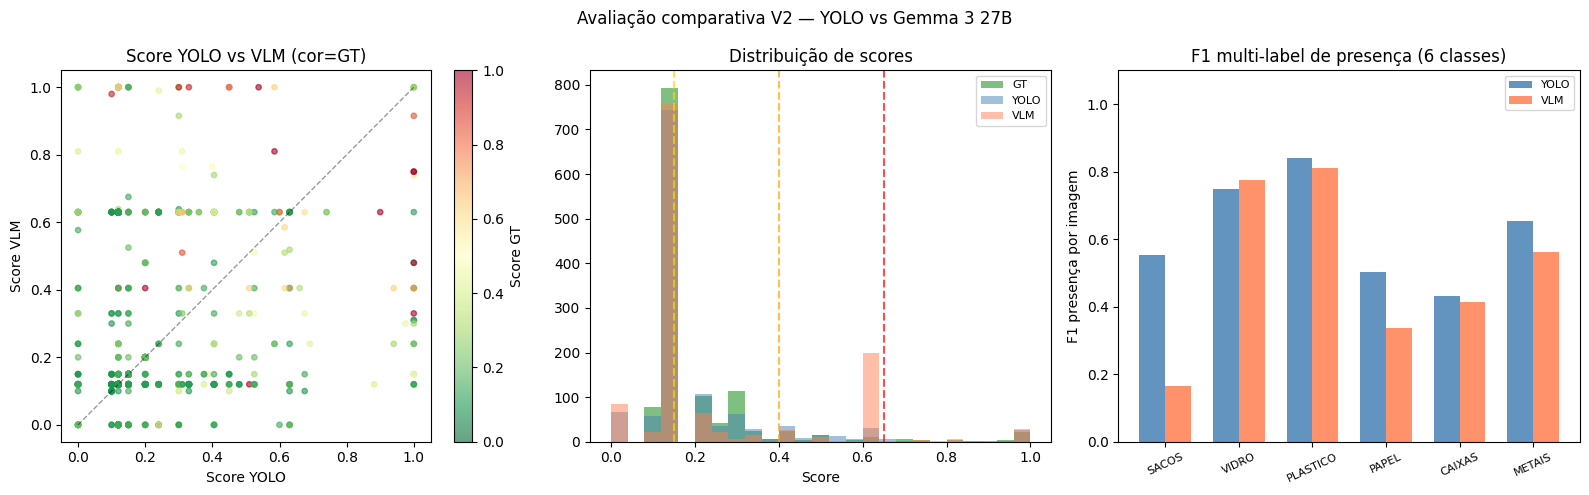

✅ fig_avaliacao_v2.png


In [180]:
# [42]
# Figuras de score e F1
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter score
sc = axes[0].scatter(yolo_sc, vlm_sc, c=gt_sc, cmap='RdYlGn_r',
                     alpha=0.6, s=15, vmin=0, vmax=1)
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('Score YOLO'); axes[0].set_ylabel('Score VLM')
axes[0].set_title('Score YOLO vs VLM (cor=GT)')
plt.colorbar(sc, ax=axes[0], label='Score GT')

# Histograma sobreposto
bins = np.linspace(0,1,26)
axes[1].hist(gt_sc,   bins=bins, alpha=0.5, label='GT',   color='green')
axes[1].hist(yolo_sc, bins=bins, alpha=0.5, label='YOLO', color='steelblue')
axes[1].hist(vlm_sc,  bins=bins, alpha=0.5, label='VLM',  color='coral')
for thr,col in [(0.15,'gold'),(0.40,'orange'),(0.65,'red')]:
    axes[1].axvline(thr,color=col,ls='--',alpha=0.7)
axes[1].set_xlabel('Score'); axes[1].set_title('Distribuição de scores')
axes[1].legend(fontsize=8)

# F1 por classe
x = np.arange(6); w = 0.35
axes[2].bar(x-w/2, f1_yolo_per, w, label='YOLO', color='steelblue', alpha=0.85)
axes[2].bar(x+w/2, f1_vlm_per,  w, label='VLM',  color='coral',     alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(CLASSES_LIST, rotation=25, fontsize=8)
axes[2].set_ylabel('F1 presença por imagem'); axes[2].set_ylim(0,1.1)
axes[2].set_title('F1 multi-label de presença (6 classes)')
axes[2].legend(fontsize=8)

fig.suptitle('Avaliação comparativa V2 — YOLO vs Gemma 3 27B', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'fig_avaliacao_v2.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ fig_avaliacao_v2.png')


In [184]:
# [43]
# Análise estratificada por dataset de origem
def calcular_f1_presenca(preds: list, gts: list) -> float:
    y_t, y_p = [], []
    for pred, gt in zip(preds, gts):
        tv = [1 if c in set(gt.get('classes',[])) else 0 for c in CLASSES_LIST]
        pv = [1 if c in set(pred.get('classes_detectadas',[])) else 0 for c in CLASSES_LIST]
        y_t.append(tv); y_p.append(pv)
    return float(f1_score(np.array(y_t), np.array(y_p), average='macro', zero_division=0))


dominios = {'td_': 'Trash Detection', 'ld_': 'Litter Detection', 'taco_': 'TACO'}
dom_rows  = []

for prefixo, nome in dominios.items():
    dom_scores = [s for s in scores_v2 if s['image_id'].startswith(prefixo)]
    if not dom_scores: continue
    dom_yolo = [yolo_map_ev.get(s['image_id'],{}) for s in dom_scores]
    dom_vlm  = [vlm_map_ev.get(s['image_id'],{})  for s in dom_scores]
    dom_gt   = [s['ground_truth']                  for s in dom_scores]

    f1_yo = calcular_f1_presenca(dom_yolo, dom_gt)
    f1_vl = calcular_f1_presenca(
        [{**v, 'classes_detectadas': v.get('classes_detectadas',[])} for v in dom_vlm], dom_gt)
    mae_yo = float(np.mean([abs(s['yolo']['score'] - s['ground_truth']['score']) for s in dom_scores]))
    mae_vl = float(np.mean([abs(s['vlm']['score']  - s['ground_truth']['score']) for s in dom_scores]))
    cnt_mae_yo = mae_contagem_por_classe(dom_yolo, dom_gt, CLASSES_LIST)
    cnt_mae_vl = mae_contagem_por_classe(dom_vlm,  dom_gt, CLASSES_LIST)

    dom_rows.append({
        'Dataset': nome, 'N': len(dom_scores),
        'F1 YOLO (presença)': round(f1_yo,4), 'F1 VLM (presença)': round(f1_vl,4),
        'MAE score YOLO': round(mae_yo,4),     'MAE score VLM': round(mae_vl,4),
        'MAE cnt YOLO':   cnt_mae_yo['macro'], 'MAE cnt VLM': cnt_mae_vl['macro'],
    })
    print(f'{nome} (n={len(dom_scores)}): F1 YOLO={f1_yo:.3f} VLM={f1_vl:.3f}  '
          f'MAEscore YOLO={mae_yo:.3f} VLM={mae_vl:.3f}')

df_dom = pd.DataFrame(dom_rows)
df_dom.to_csv('outputs/analise_por_dataset_v2.csv', index=False)
print('\n✅ outputs/analise_por_dataset_v2.csv')


KeyError: 'macro'

In [ ]:
# [44]
# Figura de análise por dataset
if len(dom_rows) > 0:
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    ds_names = df_dom['Dataset'].tolist()
    x = np.arange(len(ds_names)); w = 0.35

    axes[0].bar(x-w/2, df_dom['F1 YOLO (presença)'], w, label='YOLO', color='steelblue', alpha=0.85)
    axes[0].bar(x+w/2, df_dom['F1 VLM (presença)'],  w, label='VLM',  color='coral',     alpha=0.85)
    axes[0].set_xticks(x); axes[0].set_xticklabels(ds_names, rotation=15)
    axes[0].set_ylabel('F1 multi-label presença'); axes[0].set_ylim(0,1.1)
    axes[0].set_title('F1 de presença por dataset de origem'); axes[0].legend()

    axes[1].bar(x-w/2, df_dom['MAE score YOLO'], w, label='YOLO', color='steelblue', alpha=0.85)
    axes[1].bar(x+w/2, df_dom['MAE score VLM'],  w, label='VLM',  color='coral',     alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(ds_names, rotation=15)
    axes[1].set_ylabel('MAE score'); axes[1].set_title('MAE de score por dataset'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'fig_estratificado_dataset.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✅ fig_estratificado_dataset.png')


In [ ]:
# [45]
# Boxplot de latência com nomenclatura correta
lats_yolo_e2e = [p['latencia_end_to_end_ms']  for p in yolo_preds_v2]
lats_yolo_mod = [p['latencia_model_only_ms']  for p in yolo_preds_v2]
lats_vlm_e2e  = [p['latencia_end_to_end_ms']  for p in vlm_preds_v2
                 if 'latencia_end_to_end_ms'  in p and not p.get('erro')]
lats_vlm_srv  = [p['latencia_server_only_ms'] for p in vlm_preds_v2
                 if 'latencia_server_only_ms' in p and not p.get('erro')]

lat_yolo_mean = float(np.mean(lats_yolo_mod))
lat_vlm_mean  = float(np.mean(lats_vlm_srv))
fator_vel     = lat_vlm_mean / lat_yolo_mean if lat_yolo_mean > 0 else 0

fig, ax = plt.subplots(figsize=(8,5))
data_bp = [lats_yolo_mod, lats_yolo_e2e, lats_vlm_srv, lats_vlm_e2e]
labels_bp = ['YOLO\nmodel-only','YOLO\nend-to-end','VLM\nserver-only','VLM\nend-to-end']
bp = ax.boxplot(data_bp, labels=labels_bp, patch_artist=True, medianprops=dict(color='black',lw=2))
cores = ['#4e9af1','#9ecbf5','#f4845f','#f9c4b4']
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
ax.set_yscale('log'); ax.set_ylabel('ms/imagem (log)')
ax.set_title(f'Latência de inferência — YOLO vs VLM\nFator de velocidade (model-only): {fator_vel:.0f}×')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'fig_latencia_v2.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ fig_latencia_v2.png')


In [ ]:
# [46]
# CSV tidy e tabela LaTeX
vram_pico_gb = torch.cuda.max_memory_allocated() / 1e9
tidy_v2 = []
for i, cls_name in enumerate(CLASSES_LIST):
    tidy_v2 += [
        {'model':'YOLO','metric':'F1_presenca',   'classe':cls_name,'value':float(f1_yolo_per[i])},
        {'model':'VLM', 'metric':'F1_presenca',   'classe':cls_name,'value':float(f1_vlm_per[i])},
        {'model':'YOLO','metric':'MAE_contagem',  'classe':cls_name,'value':mae_cnt_yolo[cls_name]},
        {'model':'VLM', 'metric':'MAE_contagem',  'classe':cls_name,'value':mae_cnt_vlm[cls_name]},
    ]
for model,f1m,mae_s,conc,sp,lat_mod,lat_e2e in [
    ('YOLO',f1_yolo_mac,mae_yolo,conc_yolo,sp_yolo,lat_yolo_mean,np.mean(lats_yolo_e2e)),
    ('VLM', f1_vlm_mac, mae_vlm, conc_vlm, sp_vlm, lat_vlm_mean, np.mean(lats_vlm_e2e)),
]:
    tidy_v2 += [
        {'model':model,'metric':'F1_presenca_macro','classe':'global','value':f1m},
        {'model':model,'metric':'MAE_score',         'classe':'global','value':mae_s},
        {'model':model,'metric':'Concordancia',      'classe':'global','value':conc},
        {'model':model,'metric':'Spearman',           'classe':'global','value':sp},
        {'model':model,'metric':'Lat_model_only_ms', 'classe':'global','value':lat_mod},
        {'model':model,'metric':'Lat_end_to_end_ms', 'classe':'global','value':lat_e2e},
    ]
tidy_v2 += [
    {'model':'YOLO','metric':'mAP50',             'classe':'global','value':map_v2['mAP50']},
    {'model':'YOLO','metric':'mAP50-95',           'classe':'global','value':map_v2['mAP50-95']},
    {'model':'YOLO','metric':'Fator_velocidade',   'classe':'global','value':fator_vel},
    {'model':'YOLO','metric':'MAE_cnt_macro',      'classe':'global','value':mae_cnt_yolo['macro']},
    {'model':'VLM', 'metric':'MAE_cnt_macro',      'classe':'global','value':mae_cnt_vlm['macro']},
    {'model':'VLM', 'metric':'Pct_schema_valido',  'classe':'global',
     'value': sum(1 for p in vlm_preds_v2 if p.get('schema_valido',False))/max(len(vlm_preds_v2),1)},
    {'model':'VLM', 'metric':'Pct_deterministico', 'classe':'global',
     'value': float(np.mean([v['deterministico'] for v in variancia_results]))},
    {'model':'YOLO_VLM','metric':'Robustez_conclusao_sens','classe':'global',
     'value': float(sens_result['pct_yolo_melhor_mae'])},
]

pd.DataFrame(tidy_v2).to_csv('outputs/results_summary_v2.csv', index=False)
print('✅ outputs/results_summary_v2.csv')

# LaTeX
latex_rows = [
    ('mAP@50 — YOLO (object-level)',     f"{map_v2['mAP50']:.4f}",     '—'),
    ('mAP@50-95 — YOLO (object-level)',  f"{map_v2['mAP50-95']:.4f}",  '—'),
    ('F1 presença macro',                f'{f1_yolo_mac:.4f}',    f'{f1_vlm_mac:.4f}'),
    ('MAE contagem (macro)',             f'{mae_cnt_yolo["macro"]:.4f}', f'{mae_cnt_vlm["macro"]:.4f}'),
    ('MAE score irregularidade',         f'{mae_yolo:.4f}',       f'{mae_vlm:.4f}'),
    ('Concordância de nível',            f'{conc_yolo:.1%}',      f'{conc_vlm:.1%}'),
    ('Spearman score vs GT',             f'{sp_yolo:.4f}',        f'{sp_vlm:.4f}'),
    ('Latência model-only (ms)',         f'{lat_yolo_mean:.1f}',  f'{lat_vlm_mean:.1f}'),
    ('Latência end-to-end (ms)',         f'{np.mean(lats_yolo_e2e):.1f}', f'{np.mean(lats_vlm_e2e):.1f}'),
    ('Fator de velocidade',              f'{fator_vel:.0f}×',     '1×'),
    ('Schema JSON válido',               '—',                     f'{sum(1 for p in vlm_preds_v2 if p.get("schema_valido",False))/max(len(vlm_preds_v2),1):.1%}'),
    ('VLM determinístico (amostral)',    '—',                     f'{float(np.mean([v["deterministico"] for v in variancia_results])):.1%}'),
    ('Robustez conclusão (sens. ±20\\%)', f'{sens_result["pct_yolo_melhor_mae"]:.1%}', '—'),
]

with open('outputs/tabela_capitulo3_v2.tex','w',encoding='utf-8') as f:
    f.write('\\begin{table}[htbp]\n\\centering\n')
    f.write('\\caption{Comparação YOLOv11m vs Gemma 3 27B — 6 classes (versão rigor)}\n')
    f.write('\\label{tab:comparacao_v2}\n')
    f.write('\\begin{tabular}{lcc}\n\\toprule\n')
    f.write('\\textbf{Métrica} & \\textbf{YOLOv11m} & \\textbf{Gemma 3 27B} \\\\\n')
    f.write('\\midrule\n')
    for m,yo,vl in latex_rows:
        f.write(f'{m} & {yo} & {vl} \\\\\n')
    f.write('\\bottomrule\n\\end{tabular}\n\\end{table}\n')
print('✅ outputs/tabela_capitulo3_v2.tex')


In [ ]:
# [47]
# Resumo executivo final
print('═' * 70)
print('  RESUMO EXECUTIVO V2 — YOLO vs Gemma 3 27B (6 classes, rigor)')
print('═' * 70)
print()
print(f'HARDWARE: {torch.cuda.get_device_name(0)}')
print(f'VRAM pico: {vram_pico_gb:.1f} GB / 24 GB')
print()
print('INTEGRIDADE DO SPLIT')
print(f'  Dedup pHash aplicada: ✅')
print(f'  Split agrupado anti-vazamento: ✅  (assertion passou)')
print(f'  Prompt hash VLM: {PROMPT_HASH}')
print()
print('DETECÇÃO — YOLO (object-level)')
print(f'  mAP@50:    {map_v2["mAP50"]:.4f}')
print(f'  mAP@50-95: {map_v2["mAP50-95"]:.4f}')
print()
print('PRESENÇA POR IMAGEM (F1 multi-label, ambos os modelos)')
print(f'  YOLO macro: {f1_yolo_mac:.4f}  |  VLM macro: {f1_vlm_mac:.4f}')
print()
print('CONTAGEM (MAE por item — impacta score)')
print(f'  MAE contagem YOLO: {mae_cnt_yolo["macro"]:.4f}  |  VLM: {mae_cnt_vlm["macro"]:.4f}')
print()
print('SCORE DE IRREGULARIDADE (annotation-derived)')
print(f'  MAE YOLO: {mae_yolo:.4f}  |  MAE VLM: {mae_vlm:.4f}')
print(f'  Conc YOLO: {conc_yolo:.1%}  |  Conc VLM: {conc_vlm:.1%}')
print(f'  Spearman YOLO: {sp_yolo:.4f}  |  Spearman VLM: {sp_vlm:.4f}')
print(f'  Robustez pesos ±20%: YOLO melhor em {sens_result["pct_yolo_melhor_mae"]:.1%} das configs')
print()
print('REPRODUTIBILIDADE VLM')
print(f'  Schema válido: {sum(1 for p in vlm_preds_v2 if p.get("schema_valido",False))}/{len(vlm_preds_v2)}')
pct_det_print = float(np.mean([v["deterministico"] for v in variancia_results]))
print(f'  Determinístico (amostra 20 imgs): {pct_det_print:.1%}')
print()
print('EFICIÊNCIA')
print(f'  Lat model-only — YOLO: {lat_yolo_mean:.1f} ms  |  VLM server: {lat_vlm_mean:.1f} ms')
print(f'  Fator de velocidade: {fator_vel:.0f}×')
print('═' * 70)
